In [1]:
import numpy as np
from astropy.table import Table
import matplotlib.pyplot as plt
import pandas as pd
from cloudy_fit_lib import *
from scipy.interpolate import RegularGridInterpolator
import pickle
import corner
from scipy import integrate, interpolate
import emcee

In [2]:
plt.style.use('/Users/thepoetoftwilight/Documents/CUBS/Code/science.mplstyle')

In [3]:
rootdir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/cloudy_grids/'

In [4]:
savedir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/Ions/z=1.094565/cloudy_fits/'

Obtain the UVB grid from FG20

In [5]:
fg20_z_grid, fg20_wav_grid, fg20_J_nu_grid = read_uvb('', 'fg20_galaxy.ascii')

Fetch the SED at $z=1$

In [6]:
z_test = 1

In [7]:
fg20_J_nu_test = fetch_sed(z_test, fg20_z_grid, fg20_J_nu_grid)

Specify $N_{\mathrm{HI}}$ grid points and get corresponding filenames

In [8]:
logN_HI_min = 12
logN_HI_max = 17
logN_HI_step = 0.25

logN_HI_arr = np.arange(logN_HI_min, logN_HI_max+logN_HI_step, logN_HI_step)

In [9]:
file_list = create_grid_file_list(logN_HI_arr)

Specify grid points for densities and metallicities

In [10]:
log_hdens_min = -5
log_hdens_max = 1
log_hdens_step = 0.25

log_hdens_arr = np.arange(log_hdens_min, log_hdens_max+log_hdens_step, log_hdens_step)
logU_arr = np.log10(calc_U(fg20_wav_grid, fg20_J_nu_test, 10**log_hdens_arr))

In [11]:
log_metals_min = -3
log_metals_max = 1
log_metals_step = 0.25

log_metals_arr = np.arange(log_metals_min, log_metals_max+log_metals_step, log_metals_step)

Load the final grid

In [12]:
pkl_file = open(rootdir+'final_grid.pkl', 'rb')
species_logN_samples = pickle.load(pkl_file)
pkl_file.close()

Interpolate this grid

In [13]:
species_logN_interp = {}

for s in list(species_logN_samples.keys()):
    
    species_logN_samples[s][species_logN_samples[s]==-np.inf] = -99
    
    species_logN_interp[s] = RegularGridInterpolator((logN_HI_arr, log_hdens_arr, log_metals_arr), 
                                                     species_logN_samples[s])

Enter measurements for species

In [14]:
logN_dict = {
        'HI':'14.3, -0.1, +0.1',
        'HeI':'<12.8',
        'CII':'<13.2',
        'CIII':'>13.6',
        'CIV':'13.96, -0.01, +0.01',
        'NII':'<13.2',
        'NIV':'13.0, -0.1, +0.1',
        'NV':'<13.2',
        'OII':'<13.2',
        'OIII':'14.28, -0.02, +0.02',
        'OIV':'14.67, -0.02, +0.02',
        'OV':'14.19, -0.03, +0.03',
        'OVI':'13.8, -0.2, +0.2',
        'NeVI':'<13.5',
        'NeVIII':'<13.5',
        'MgII':'<11.1',
        'MgX':'<13.6',
        'AlII':'<11.0',
        'AlIII':'<11.3',
        'SiII':'<12.1',
        'SiIII':'<11.9',
        'SIV':'<12.6',
        'SV':'<12.1',
        'SVI':'<13.4',
        'FeII':'<11.5'}

Try out a solution

In [15]:
logN_HI_test = 14.34 #14.34
log_hdens_test = -3.5
log_metals_test = 0.3

In [16]:
logN_species_test = predict_col_dens(logN_dict, logN_HI_test, log_hdens_test, 
                                     log_metals_test, species_logN_interp)

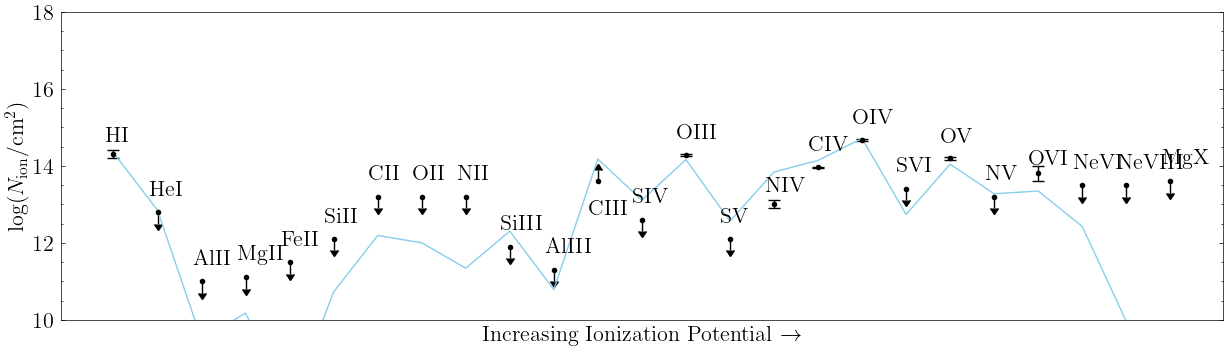

In [17]:
fig, ax = plot_column_densities_obs(logN_dict)
ax.plot(np.arange(len(logN_species_test)), np.array(logN_species_test),#+13.2-logN_species_test[7], 
        color='skyblue')

# Single phase solution

In [19]:
logN_dict = {
        #'HI':'14.3, -0.1, +0.1',
        #'HeI':'<12.8',
        #'CII':'<13.2',
        #'CIII':'>13.6',
        #'CIV':'13.96, -0.01, +0.01',
        #'NII':'<13.2',
        #'NIV':'13.0, -0.1, +0.1',
        #'NV':'<13.2',
        'OII':'<13.2',
        'OIII':'14.28, -0.02, +0.02',
        'OIV':'14.67, -0.02, +0.02',
        'OV':'<14.19',
        'OVI':'<13.8',
        'NeVI':'<13.5',
        'NeVIII':'<13.5',
        'MgII':'<11.1',
        'MgX':'<13.6',
        #'AlII':'<11.0',
        #'AlIII':'<11.3',
        #'SiII':'<12.1',
        #'SiIII':'<11.9',
        'SIV':'<12.6',
        'SV':'<12.1',
        'SVI':'<13.4',}
        #'FeII':'<11.5'}

Get column density ratios

In [28]:
gen_logN_ratio_str(logN_dict['OVI'], logN_dict['OIV'])

'<-0.87, 0.14'

In [29]:
logN_ratio_dict = {'OII/OIII': '<-1.1, 0.1',
                   'OIV/OIII': '0.39, -0.03, 0.03',
                   'OV/OIV': '<-0.5, 0.1',
                   'OVI/OIV': '<-0.9, 0.1'
                   }

Generate predicted column density ratios

(-2.0, 1.0)

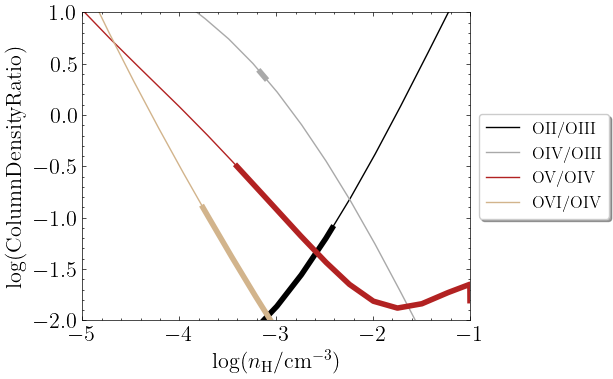

In [30]:
fig, ax = plt.subplots(1, figsize=(5,4))

plot_logN_ratio(ax, species_logN_interp, logN_ratio_dict, logN_HI_ref = 12.5, log_metals_ref=-2.5)

ax.set_xlim(-5, -1)
ax.set_ylim(-2, 1)

Fit gas density

In [31]:
def log_probability(params, logN_ratio_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    # Params here will only contain n_H and [O/H]
    
    log_hdens = params[0]
    
    lp = log_prior_hdens(log_hdens)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_hdens(log_hdens, logN_ratio_dict, species_logN_interp)

In [32]:
logN_ratio_dict

{'OII/OIII': '<-1.1, 0.1',
 'OIV/OIII': '0.39, -0.03, 0.03',
 'OV/OIV': '<-0.5, 0.1',
 'OVI/OIV': '<-0.9, 0.1'}

In [33]:
pos = np.array(-3.15) + 1e-4 * np.random.randn(500, 1)
nwalkers, ndim = pos.shape

In [34]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_ratio_dict, species_logN_interp)
)

In [35]:
sampler.run_mcmc(pos, 500, progress=True);

100%|█████████████████████████████████████████| 500/500 [06:22<00:00,  1.31it/s]


In [36]:
flat_samples_hdens = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
                                columns=['log_hdens'])

flat_samples_hdens.to_csv(savedir+'hdens_op.csv', index=False)

#flat_samples_hdens = pd.read_csv(savedir+'hdens_op.csv')

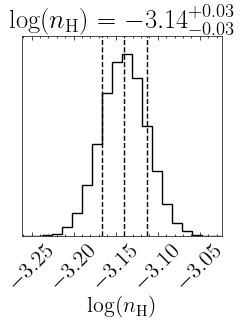

In [37]:
fig = corner.corner(
    flat_samples_hdens, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$', r'$[\mathrm{O/H}]$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [38]:
grid_points_hdens = np.array([[12, log_hdens, -3] for log_hdens in flat_samples_hdens['log_hdens']])

In [39]:
logN_offset = 14.28-np.mean(species_logN_interp['O+2'](grid_points_hdens))

Calculate the C/O ratio

In [40]:
logN_CIV_obs = np.random.normal(loc=13.96, scale=0.01, size=len(flat_samples_hdens))

In [41]:
C_O_dist_CIV = logN_CIV_obs-(logN_offset+species_logN_interp['C+3'](grid_points_hdens))
C_O_dist = C_O_dist_CIV

In [73]:
(np.round(np.median(C_O_dist), 2), 
np.round(np.percentile(C_O_dist, 100*(1-cdf_1sig))-np.median(C_O_dist), 2),
np.round(np.percentile(C_O_dist, 100*cdf_1sig)-np.median(C_O_dist), 2))

(0.08, -0.04, 0.04)

Compute N/O ratio

In [74]:
logN_NIV_obs = np.random.normal(loc=13.0, scale=0.1, size=len(flat_samples_hdens))

In [75]:
N_O_dist_NIV = logN_NIV_obs-(logN_offset+species_logN_interp['N+3'](grid_points_hdens))
N_O_dist = N_O_dist_NIV

In [76]:
(np.round(np.median(N_O_dist), 2), 
np.round(np.percentile(N_O_dist, 100*(1-cdf_1sig))-np.median(N_O_dist), 2),
np.round(np.percentile(N_O_dist, 100*cdf_1sig)-np.median(N_O_dist), 2))

(-0.8, -0.11, 0.11)

Plot models

In [44]:
logN_dict = {
        #'HI':'14.3, -0.1, +0.1',
        #'HeI':'<12.8',
        #'CII':'<13.2',
        #'CIII':'>13.6',
        #'CIV':'13.96, -0.01, +0.01',
        #'NII':'<13.2',
        #'NIV':'13.0, -0.1, +0.1',
        #'NV':'<13.2',
        'OII':'<13.2',
        'OIII':'14.28, -0.02, +0.02',
        'OIV':'14.67, -0.02, +0.02',
        'OV':'<14.19',
        'OVI':'<13.8',
        #'NeVI':'<13.5',
        #'NeVIII':'<13.5',
        'MgII':'<11.1',
        #'MgX':'<13.6',
        #'AlII':'<11.0',
        #'AlIII':'<11.3',
        #'SiII':'<12.1',
        #'SiIII':'<11.9',
        'SIV':'<12.6',
        'SV':'<12.1',
        'SVI':'<13.4',}
        #'FeII':'<11.5'}

In [45]:
sample_indices_hdens = np.random.randint(low=0, high=len(flat_samples_hdens), size=200)

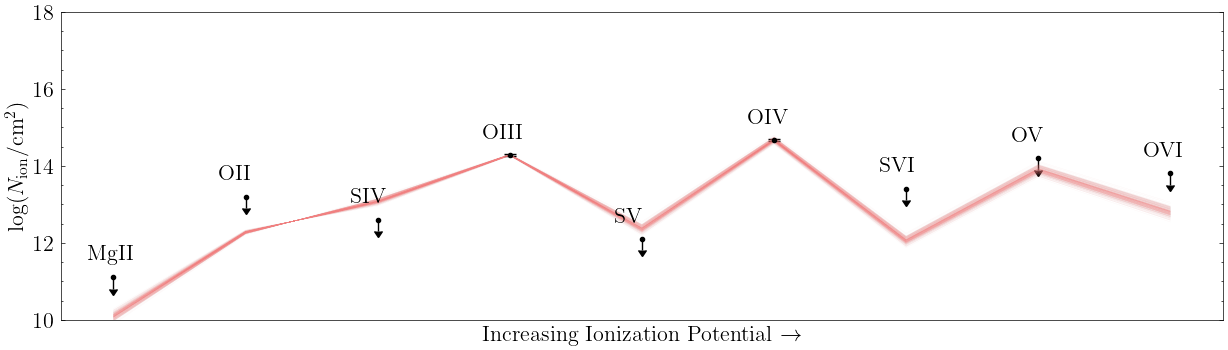

In [47]:
fig, ax = plot_column_densities_obs(logN_dict)

for i in range(len(sample_indices_hdens)):
    
    idx = sample_indices_hdens[i]
    flat_samples_row = flat_samples_hdens.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    
    logN_species_test = predict_col_dens(logN_dict, 12, log_hdens, 
                                         -3, species_logN_interp,) #{'N': np.median(N_O_dist),
                                                                  # 'C': np.median(C_O_dist)})

    # Plot
    ax.plot(np.arange(len(logN_species_test)), 
            np.array(logN_species_test)+logN_offset,
            color='lightcoral', lw=.2, alpha=.1)

Get cloud sizes

In [48]:
l_dist = np.array([get_cloud_size(14.3, log_hdens, species_logN_interp) for log_hdens in flat_samples_hdens['log_hdens']])

(array([1.3000e+01, 2.9000e+01, 7.8000e+01, 1.6800e+02, 6.5400e+02,
        1.1460e+03, 2.1350e+03, 3.5620e+03, 5.2880e+03, 7.7420e+03,
        9.5660e+03, 1.2671e+04, 1.4707e+04, 1.5966e+04, 1.6771e+04,
        1.6629e+04, 1.5747e+04, 1.4352e+04, 1.3098e+04, 1.1331e+04,
        9.3630e+03, 7.2800e+03, 5.7730e+03, 4.5530e+03, 3.3900e+03,
        2.5040e+03, 1.7230e+03, 1.2450e+03, 7.8100e+02, 6.0400e+02,
        4.1900e+02, 2.4500e+02, 1.6400e+02, 9.2000e+01, 5.9000e+01,
        5.5000e+01, 3.7000e+01, 2.4000e+01, 1.1000e+01, 6.0000e+00,
        8.0000e+00, 1.0000e+00, 1.0000e+00, 8.0000e+00, 1.0000e+00]),
 array([0.21614402, 0.22715455, 0.23816509, 0.24917562, 0.26018615,
        0.27119668, 0.28220722, 0.29321775, 0.30422828, 0.31523881,
        0.32624935, 0.33725988, 0.34827041, 0.35928094, 0.37029148,
        0.38130201, 0.39231254, 0.40332307, 0.41433361, 0.42534414,
        0.43635467, 0.4473652 , 0.45837574, 0.46938627, 0.4803968 ,
        0.49140733, 0.50241787, 0.5134284 , 0.

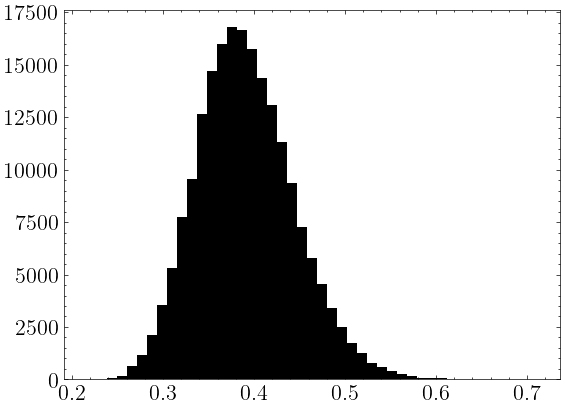

In [49]:
plt.hist(l_dist, bins=45)

# Two-phase solution

Let's do a high density phase, varying all three parameters. And a low density phase, fixed density, vary HI and metallicity.

In [50]:
def log_probability(params, logN_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    # Params here will only contain n_H and [O/H]
    
    lp = log_prior_tp(params, species_logN_interp)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_tp(params, logN_dict, species_logN_interp)

Plot some solutions

In [52]:
logN_dict = {
        'HI':'14.3, -0.1, +0.1',
        #'HeI':'<12.8',
        #'CII':'<13.2',
        #'CIII':'>13.6',
        #'CIV':'13.96, -0.01, +0.01',
        #'NII':'<13.2',
        #'NIV':'13.0, -0.1, +0.1',
        #'NV':'<13.2',
        'OII':'<13.2',
        'OIII':'14.28, -0.02, +0.02',
        'OIV':'14.67, -0.02, +0.02',
        'OV':'<14.19',
        'OVI':'<13.8',
        #'NeVI':'<13.5',
        #'NeVIII':'<13.5',
        'MgII':'<11.1',}
        #'MgX':'<13.6',
        #'AlII':'<11.0',
        #'AlIII':'<11.3',
        #'SiII':'<12.1',
        #'SiIII':'<11.9',
        #'SIV':'<12.6',
        #'SV':'<12.1',
        #'SVI':'<13.4',}
        #'FeII':'<11.5'}

In [68]:
logN_HI_p1_test = 14.1
log_hdens_p1_test = -1
log_metals_p1_test = -1

logN_HI_p2_test = 13.9
log_hdens_p2_test = -3.1
log_metals_p2_test = 0.7

In [69]:
logN_species_test_p1 = np.array(predict_col_dens(logN_dict, 
                                                 logN_HI_p1_test, 
                                                 log_hdens_p1_test, 
                                                 log_metals_p1_test, 
                                                 species_logN_interp))

logN_species_test_p2 = np.array(predict_col_dens(logN_dict, 
                                                 logN_HI_p2_test, 
                                                 log_hdens_p2_test, 
                                                 log_metals_p2_test, 
                                                 species_logN_interp))


logN_species_test = np.log10(10**logN_species_test_p1 + 10**logN_species_test_p2)

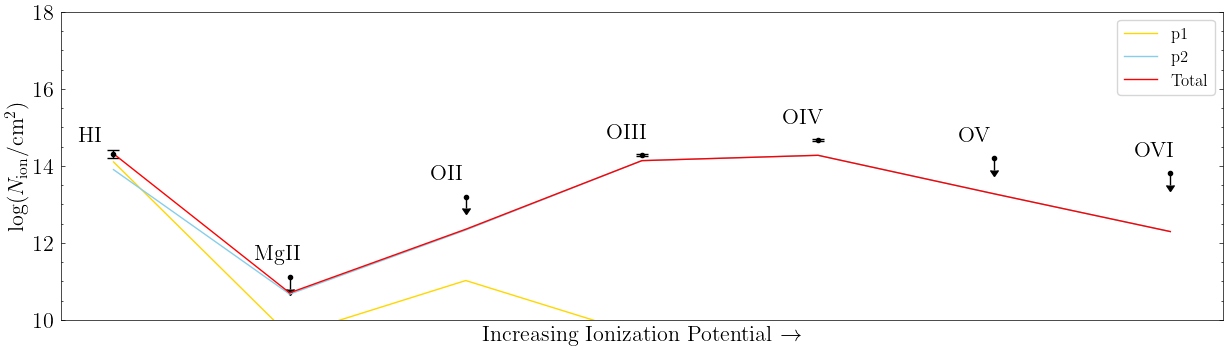

In [70]:
fig, ax = plot_column_densities_obs(logN_dict)

ax.plot(np.arange(len(logN_species_test)), logN_species_test_p1, color='gold', label='p1')
ax.plot(np.arange(len(logN_species_test)), logN_species_test_p2, color='skyblue', label='p2')
ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='red', label='Total')

ax.legend()

In [71]:
pos = np.array([logN_HI_p1_test, log_hdens_p1_test, log_metals_p1_test,
                logN_HI_p2_test, log_hdens_p2_test, log_metals_p2_test]) + 1e-4 * np.random.randn(500, 6)
nwalkers, ndim = pos.shape

In [72]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_dict, species_logN_interp)
)

In [73]:
sampler.run_mcmc(pos, 500, progress=True);

100%|█████████████████████████████████████████| 500/500 [08:36<00:00,  1.03s/it]


In [74]:
flat_samples_tp = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
                                columns=['logN_HI_p1', 'log_hdens_p1', 'log_metals_p1',
                                         'logN_HI_p2', 'log_hdens_p2', 'log_metals_p2'])
flat_samples_tp.to_csv(savedir+'tp.csv', index=False)

#flat_samples_tp = pd.read_csv(savedir+'tp.csv')

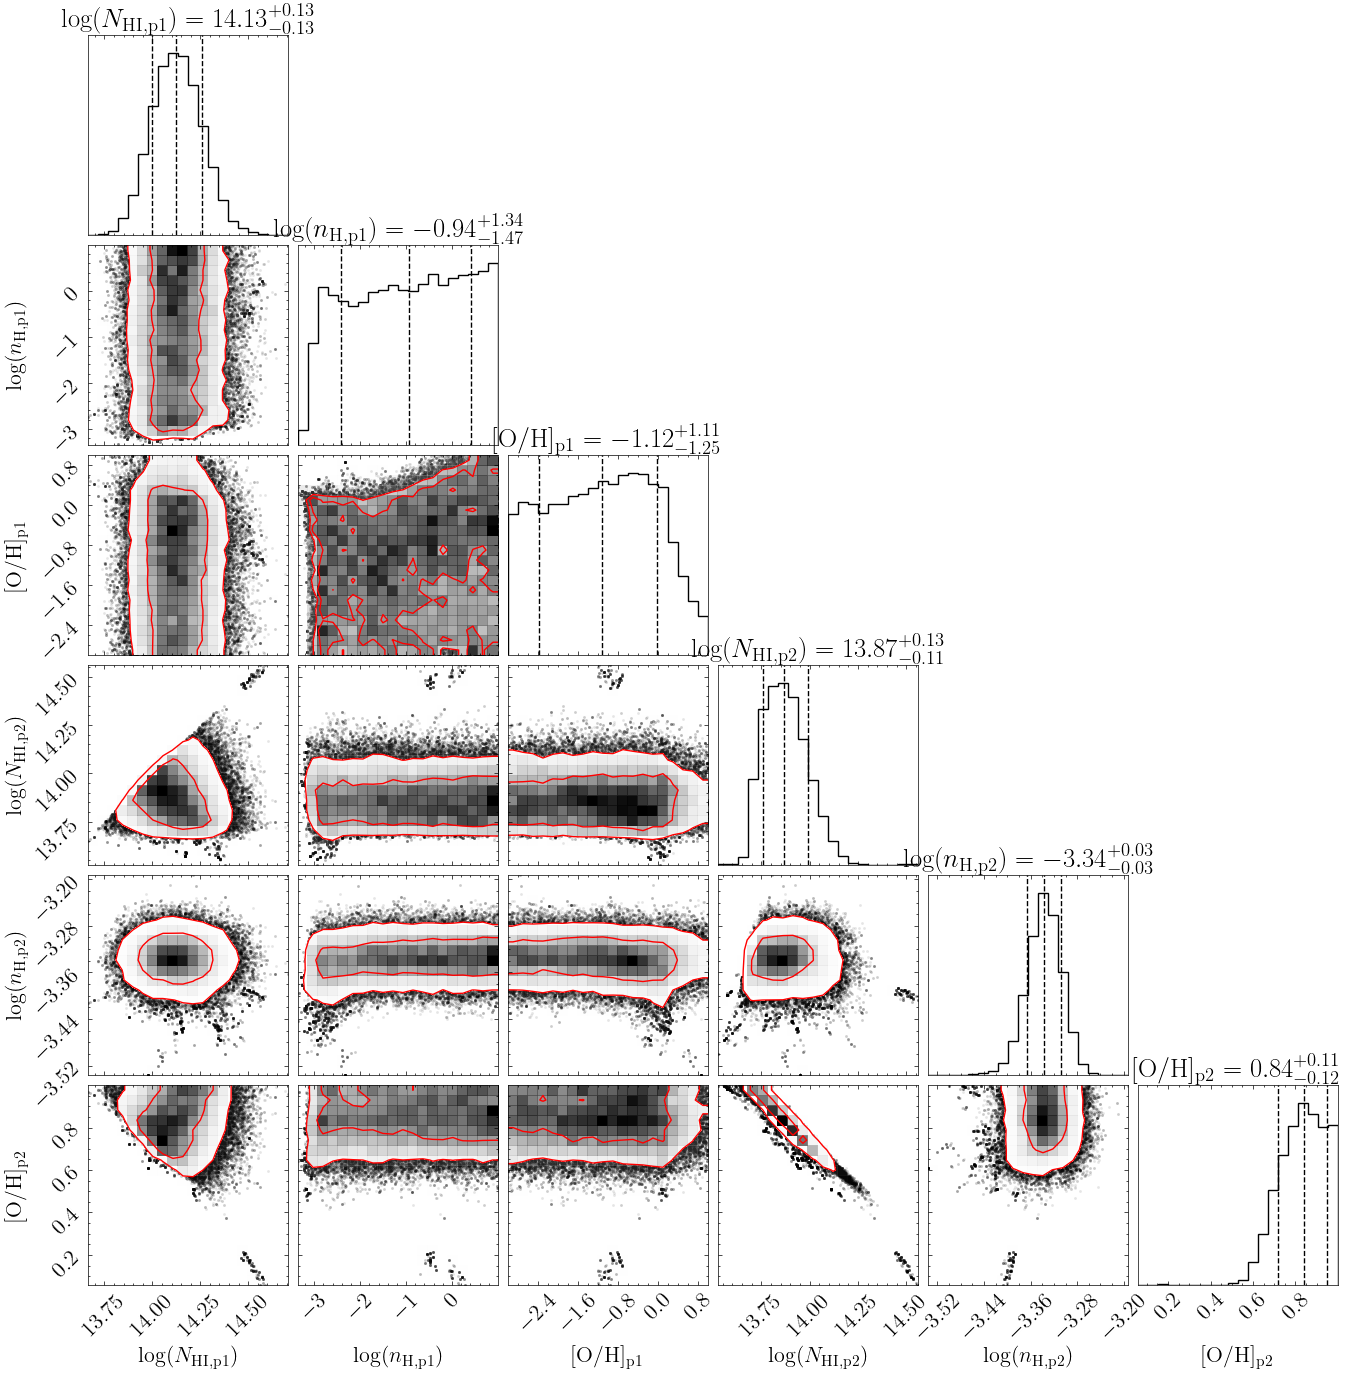

In [75]:
fig = corner.corner(
    flat_samples_tp, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(N_\mathrm{HI, p1})$', r'$\log(n_\mathrm{H, p1})$', r'$[\mathrm{O/H}]_{\mathrm{p1}}$',
            r'$\log(N_\mathrm{HI, p2})$', r'$\log(n_\mathrm{H, p2})$', r'$[\mathrm{O/H}]_{\mathrm{p2}}$',], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

Get cloud sizes

In [76]:
l_hi_dist = np.zeros(len(flat_samples_tp))

for i in range(len(flat_samples_tp)):
    
    flat_samples_row = flat_samples_tp.iloc[i]

    l_hi_dist[i] = get_cloud_size(flat_samples_row['logN_HI_p1'], flat_samples_row['log_hdens_p1'], 
                                    species_logN_interp, flat_samples_row['log_metals_p1'])

In [77]:
l_lo_dist = np.zeros(len(flat_samples_tp))

for i in range(len(flat_samples_tp)):
    
    flat_samples_row = flat_samples_tp.iloc[i]

    l_lo_dist[i] = get_cloud_size(flat_samples_row['logN_HI_p2'], flat_samples_row['log_hdens_p2'], 
                                    species_logN_interp, flat_samples_row['log_metals_p2'])

Text(0, 0.5, 'Counts')

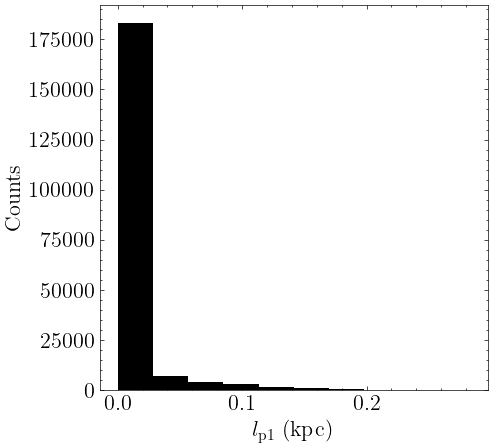

In [94]:
fig, ax = plt.subplots(1, figsize=(5,5))

ax.hist(l_hi_dist, bins=10)

ax.set_xlabel(r'$l_{\mathrm{p1}}$ (kpc)')
ax.set_ylabel('Counts')

#ax.set_xlim(0,1000)

In [95]:
1000*np.median(l_hi_dist)

0.005709913085808715

Text(0, 0.5, 'Counts')

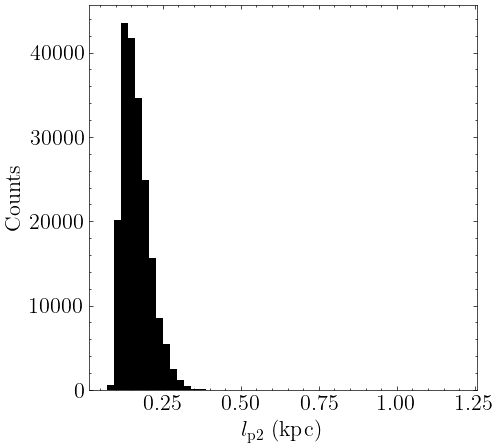

In [96]:
fig, ax = plt.subplots(1, figsize=(5,5))

ax.hist(l_lo_dist, bins=50)

ax.set_xlabel(r'$l_{\mathrm{p2}}$ (kpc)')
ax.set_ylabel('Counts')

In [97]:
np.median(l_lo_dist)

0.15820129715684514

Text(0, 0.5, '$l_{\\mathrm{p2}}$ (kpc)')

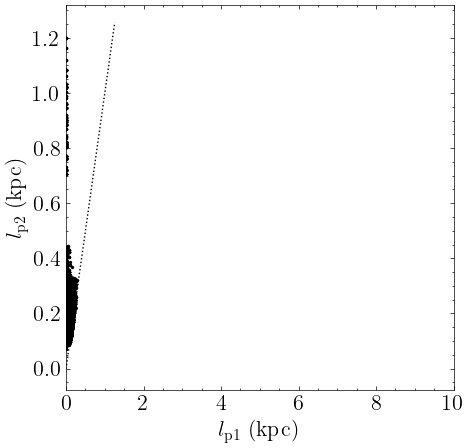

In [98]:
fig, ax = plt.subplots(1, figsize=(5,5))
ax.scatter(l_hi_dist, l_lo_dist, s=2)

lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
    np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
]

# now plot both limits against eachother
ax.plot(lims, lims, linestyle=':')

ax.set_xlim(0, 10)

ax.set_xlabel(r'$l_{\mathrm{p1}}$ (kpc)')
ax.set_ylabel(r'$l_{\mathrm{p2}}$ (kpc)')

Now plot the best models

In [83]:
logN_dict = {
        'HI':'14.3, -0.1, +0.1',
        #'HeI':'<12.8',
        #'CII':'<13.2',
        #'CIII':'>13.6',
        #'CIV':'13.96, -0.01, +0.01',
        #'NII':'<13.2',
        #'NIV':'13.0, -0.1, +0.1',
        #'NV':'<13.2',
        'OII':'<13.2',
        'OIII':'14.28, -0.02, +0.02',
        'OIV':'14.67, -0.02, +0.02',
        'OV':'<14.19',
        'OVI':'<13.8',
        #'NeVI':'<13.5',
        #'NeVIII':'<13.5',
        'MgII':'<11.1',}
        #'MgX':'<13.6',
        #'AlII':'<11.0',
        #'AlIII':'<11.3',
        #'SiII':'<12.1',
        #'SiIII':'<11.9',
        #'SIV':'<12.6',
        #'SV':'<12.1',
        #'SVI':'<13.4',}
        #'FeII':'<11.5'}

In [84]:
sample_indices_tp = np.random.randint(low=0, high=len(flat_samples_tp), size=200)

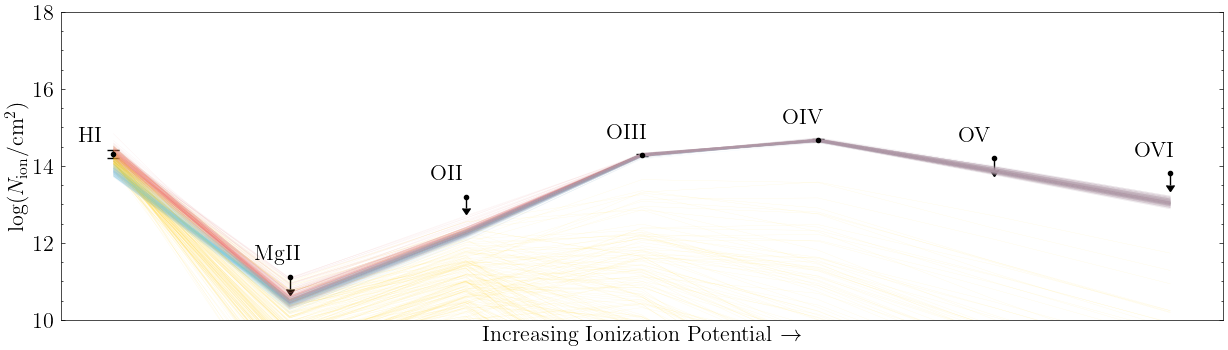

In [85]:
fig, ax = plot_column_densities_obs(logN_dict)

for i in range(len(sample_indices_tp)):
    
    idx = sample_indices_tp[i]
    flat_samples_row = flat_samples_tp.iloc[i]
    
    logN_HI_p1 = flat_samples_row['logN_HI_p1']
    log_hdens_p1 = flat_samples_row['log_hdens_p1']
    log_metals_p1 = flat_samples_row['log_metals_p1']

    logN_species_test_p1 = np.array(predict_col_dens(logN_dict, logN_HI_p1, log_hdens_p1, 
                                         log_metals_p1, species_logN_interp))
    
    logN_HI_p2 = flat_samples_row['logN_HI_p2']
    log_hdens_p2 = flat_samples_row['log_hdens_p2']
    log_metals_p2 = flat_samples_row['log_metals_p2']
    
    logN_species_test_p2 = np.array(predict_col_dens(logN_dict, logN_HI_p2, log_hdens_p2, 
                                         log_metals_p2, species_logN_interp))
    
    logN_species_test = np.log10(10**logN_species_test_p1 + 10**logN_species_test_p2)
        
    # Plot
    ax.plot(np.arange(len(logN_species_test)), logN_species_test_p1, color='gold', lw=.2, alpha=.15)
    ax.plot(np.arange(len(logN_species_test)), logN_species_test_p2, color='skyblue', lw=.2, alpha=.15)

    ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='lightcoral', lw=.2, alpha=.15)

In [86]:
1000*get_cloud_size(12, 1, species_logN_interp)

4.729898965319998e-08

# Low density phase

In [207]:
def log_probability(params, logN_ratio_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    # Params here will only contain n_H and [O/H]
    
    log_hdens = params[0]
    
    lp = log_prior_hdens(log_hdens)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_hdens(log_hdens, logN_ratio_dict, species_logN_interp)

In [208]:
logN_dict = {
        #'HI':'14.3, -0.1, +0.1',
        #'HeI':'<12.8',
        #'CII':'<13.2',
        'CIII':'>13.6',
        'CIV':'13.96, -0.01, +0.01',
        'NII':'<13.2',
        'NIV':'13.0, -0.1, +0.1',
        'NV':'<13.2',
        #'OII':'<13.2',
        'OIII':'<14.28',
        'OIV':'14.67, -0.02, +0.02',
        'OV':'<14.19',
        'OVI':'<13.8',
        'NeVI':'<13.5',
        'NeVIII':'<13.5',
        #'MgII':'<11.1',
        'MgX':'<13.6',
        #'AlII':'<11.0',
        #'AlIII':'<11.3',
        #'SiII':'<12.1',
        #'SiIII':'<11.9',
        'SIV':'<12.6',
        'SV':'<12.1',
        'SVI':'<13.4',}
        #'FeII':'<11.5'}

Get column density ratios

In [209]:
gen_logN_ratio_str(logN_dict['SIV'], logN_dict['OIV'])

'<-2.07, 0.14'

In [210]:
logN_ratio_dict = {#'SIV/OIV' : '<-2.1, 0.1',
                   'OVI/OIV' : '<-0.9, 0.1',
                   'OV/OIV': '<-0.5, 0.1',
                   'OIII/OIV': '<-0.4, 0.2',
                   'NeVIII/OIV': '<-1.1, 0.2',
                   'CIII/CIV': '>-0.4, 0.3',
                   'NV/NIV': '<0.2, 0.2',
                   'NII/NIV': '<0.2, 0.2'
                  }

(-5.0, 5.0)

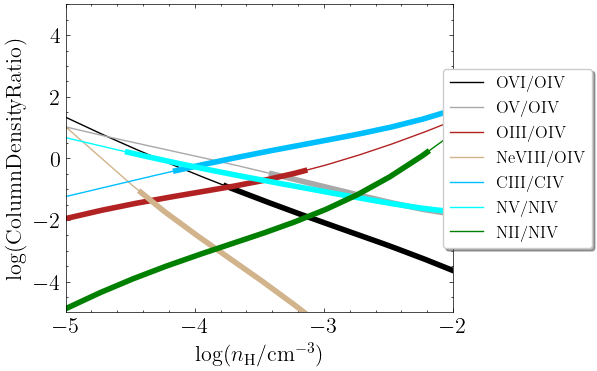

In [211]:
fig, ax = plt.subplots(1, figsize=(5,4))

plot_logN_ratio(ax, species_logN_interp, logN_ratio_dict)

ax.set_xlim(-5, -2)
ax.set_ylim(-5, 5)

In [212]:
def log_probability(params, logN_ratio_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    # Params here will only contain n_H and [O/H]
    
    log_hdens = params[0]
    
    lp = log_prior_hdens(log_hdens)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_hdens(log_hdens, logN_ratio_dict, species_logN_interp)

In [213]:
#pos = np.array(-3.2) + 1e-6 * np.random.randn(500, 1)
#nwalkers, ndim = pos.shape

In [214]:
#sampler = emcee.EnsembleSampler(
#    nwalkers, ndim, log_probability, args=(logN_ratio_dict, species_logN_interp)
#)

In [215]:
#sampler.run_mcmc(pos, 500, progress=True);

In [216]:
#flat_samples_hdens = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
#                                columns=['log_hdens'])

#flat_samples_hdens.to_csv(savedir+'hdens_lo.csv', index=False)

flat_samples_hdens = pd.read_csv(savedir+'hdens_lo.csv')

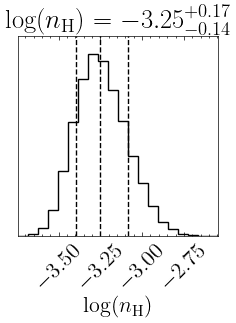

In [217]:
fig = corner.corner(
    flat_samples_hdens, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [218]:
grid_points_hdens = np.array([[12, log_hdens, -3] for log_hdens in flat_samples_hdens['log_hdens']])

In [219]:
hist, bins = np.histogram(species_logN_interp['O+3'](grid_points_hdens), bins=1000)
centers = .5*(bins[1:]+bins[:-1])

Text(0.5, 0, '$\\log N_{\\mathrm{OIV, ref}}$')

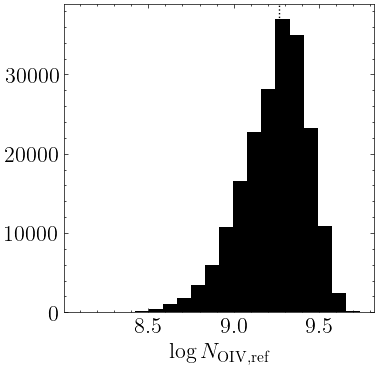

In [220]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(species_logN_interp['O+3'](grid_points_hdens), bins=20)
ax.axvline(np.median(species_logN_interp['O+3'](grid_points_hdens)), linestyle=':')
ax.set_xlabel(r'$\log N_{\mathrm{OIV, ref}}$')

#ax.set_xlim(9.8, 9.9)

Text(0.5, 0, '$\\log N_{\\mathrm{OIII, ref}}$')

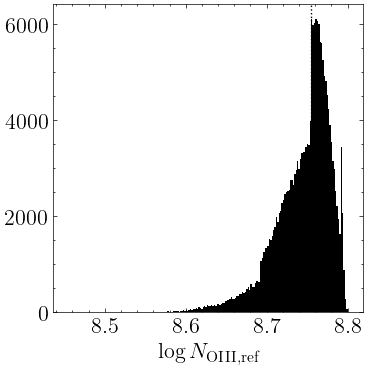

In [221]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(species_logN_interp['O+2'](grid_points_hdens), bins=200)
ax.axvline(np.median(species_logN_interp['O+2'](grid_points_hdens)), linestyle=':')
ax.set_xlabel(r'$\log N_{\mathrm{OIII, ref}}$')

#ax.set_xlim(9.8, 9.9)

Text(0.5, 0, '$\\log N_{\\mathrm{CIII, ref}}$')

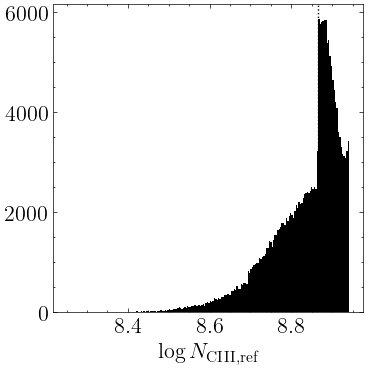

In [222]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(species_logN_interp['C+2'](grid_points_hdens), bins=200)
ax.axvline(np.median(species_logN_interp['C+2'](grid_points_hdens)), linestyle=':')
ax.set_xlabel(r'$\log N_{\mathrm{CIII, ref}}$')

#ax.set_xlim(9.8, 9.9)

Get the offset

In [223]:
logN_offset = 14.67-np.median(species_logN_interp['O+3'](grid_points_hdens))

In [224]:
logN_offset

5.401908575012115

Calculate the C/O ratio

In [225]:
logN_CIV_obs = np.random.normal(loc=13.96, scale=0.01, size=len(flat_samples_hdens))

In [226]:
C_O_dist_CIV = logN_CIV_obs-(logN_offset+species_logN_interp['C+3'](grid_points_hdens))
C_O_dist = C_O_dist_CIV

In [227]:
get_quantiles(C_O_dist)

0.07 -0.16 0.25


Calculate the N/O ratio

In [228]:
logN_NIV_obs = np.random.normal(loc=13.0, scale=0.1, size=len(flat_samples_hdens))

In [229]:
N_O_dist_NIV = logN_NIV_obs-(logN_offset+species_logN_interp['N+3'](grid_points_hdens))
N_O_dist = N_O_dist_NIV

In [230]:
get_quantiles(N_O_dist)

-0.82 -0.22 0.27


Get yields

In [231]:
get_quantiles(logN_offset+species_logN_interp['O+2'](grid_points_hdens))

14.16 -0.04 0.02


In [232]:
get_quantiles(logN_offset+species_logN_interp['C+2'](grid_points_hdens))

14.27 -0.12 0.04


In [233]:
get_quantiles(logN_offset+species_logN_interp['S+3'](grid_points_hdens))

13.07 -0.22 0.13


In [234]:
12.6-13.07

-0.47000000000000064

Plot models

In [235]:
logN_dict = {
        #'HI':'14.3, -0.1, +0.1',
        #'HeI':'<12.8',
        #'CII':'<13.2',
        'CIII':'>13.6',
        'CIV':'13.96, -0.01, +0.01',
        'NII':'<13.2',
        'NIV':'13.0, -0.1, +0.1',
        'NV':'<13.2',
        #'OII':'<13.2',
        'OIII':'14.28, -0.02, +0.02',
        'OIV':'14.67, -0.02, +0.02',
        'OV':'14.19, -0.03, +0.03',
        'OVI':'13.8, -0.2, +0.2',
        'NeVI':'<13.5',
        'NeVIII':'<13.5',
        #'MgII':'<11.1',
        'MgX':'<13.6',
        #'AlII':'<11.0',
        #'AlIII':'<11.3',
        #'SiII':'<12.1',
        #'SiIII':'<11.9',
        'SIV':'<12.6',
        'SV':'<12.1',
        'SVI':'<13.4',}
        #'FeII':'<11.5'}

In [236]:
sample_indices_hdens = np.random.randint(low=0, high=len(flat_samples_hdens), size=200)

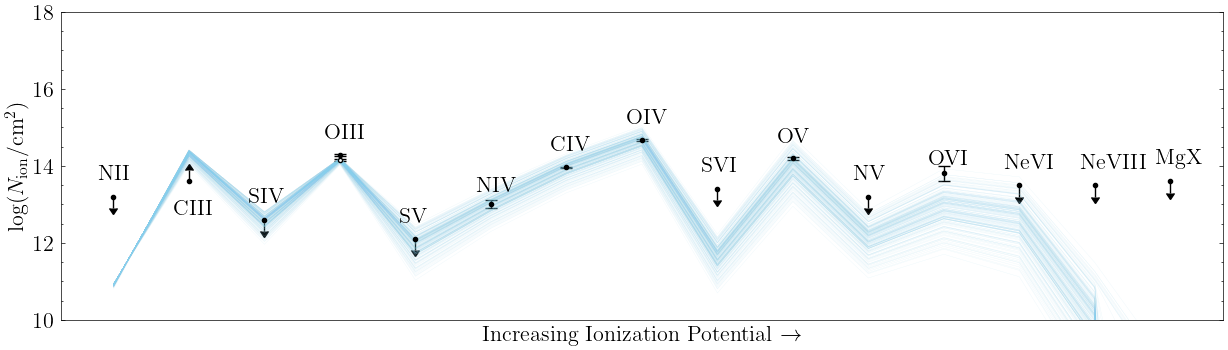

In [237]:
fig, ax = plot_column_densities_obs(logN_dict)

ax.errorbar(x=3, y=14.16, yerr=[[0.04],[0.02]], color='black', linestyle='None', mfc='white',
        fmt='o', markersize=3, capsize=4)

#ax.errorbar(x=1, y=13.98, yerr=0.08, color='black', linestyle='None', mfc='white',
#        fmt='o', markersize=3, capsize=4)

for i in range(len(sample_indices_hdens)):
    
    idx = sample_indices_hdens[i]
    flat_samples_row = flat_samples_hdens.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    
    logN_species_test = predict_col_dens(logN_dict, 12, log_hdens, 
                                         -3, species_logN_interp,
                                        {'C':np.median(C_O_dist), 
                                         'N':np.median(N_O_dist),
                                         'S': -0.5})

    # Plot
    ax.plot(np.arange(len(logN_species_test)), 
            np.array(logN_species_test)+logN_offset,
            color='skyblue', lw=.2, alpha=.2)

Calculate residual for OIII

In [173]:
logN_OIII_tot = np.random.normal(loc=14.28, scale=0.02, size=1000)
logN_OIII_lo_dens = np.random.normal(loc=14.16, scale=0.04, size=1000)
logN_OIII_hi_dens = np.log10(10**logN_OIII_tot - 10**logN_OIII_lo_dens)

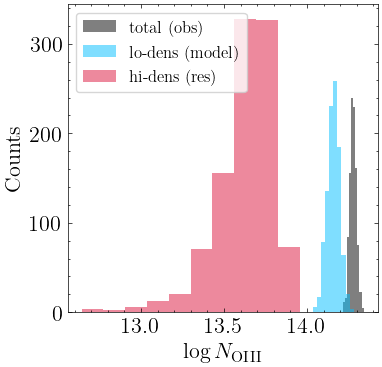

In [174]:
fig, ax = plt.subplots(1, figsize=(4,4))

ax.hist(logN_OIII_tot, label='total (obs)', alpha=0.5)
ax.hist(logN_OIII_lo_dens, label='lo-dens (model)', alpha=0.5)
ax.hist(logN_OIII_hi_dens, label='hi-dens (res)', alpha=0.5)

ax.set_xlabel(r'$\log N_{\mathrm{OIII}}$')
ax.set_ylabel('Counts')

#ax.set_xlim(13.81,14.39)
ax.legend(loc='upper left')

In [175]:
logN_OIII_hi_dens_clean = logN_OIII_hi_dens[~np.isnan(logN_OIII_hi_dens)]

In [176]:
get_quantiles(logN_OIII_hi_dens_clean)

13.66 -0.18 0.12


# High density phase

In [186]:
logN_dict = {
        #'HI':'14.3, -0.1, +0.1',
        #'HeI':'<12.8',
        #'CII':'<13.2',
        #'CIII':'>13.6',
        #'CIV':'13.96, -0.01, +0.01',
        #'NII':'<13.2',
        #'NIV':'13.0, -0.1, +0.1',
        #'NV':'<13.2',
        'OII':'<13.2',
        'OIII':'13.7, -0.2, +0.1',
        'OIV':'<14.67',
        #'OV':'14.19, -0.03, +0.03',
        #'OVI':'13.8, -0.2, +0.2',
        #'NeVI':'<13.5',
        #'NeVIII':'<13.5',
        'MgII':'<11.1',
        #'MgX':'<13.6',
        #'AlII':'<11.0',
        #'AlIII':'<11.3',
        #'SiII':'<12.1',
        #'SiIII':'<11.9',
        'SIV':'<12.6',
        'SV':'<12.1',}
        #'SVI':'<13.4',}
        #'FeII':'<11.5'}

In [188]:
gen_logN_ratio_str(logN_dict['SV'], logN_dict['OIII'])

'<-1.60, 0.17'

In [189]:
logN_ratio_dict = {
                   'OII/OIII': '<-0.5, 0.2',
                   'MgII/OIII': '<-2.6, 0.2',
                   'OIV/OIII': '<1.0, 0.2',
                    'SIV/OIII': '<-1.1, 0.2',
                    'SV/OIII': '<-1.6, 0.2'
                  }

(-5.0, 5.0)

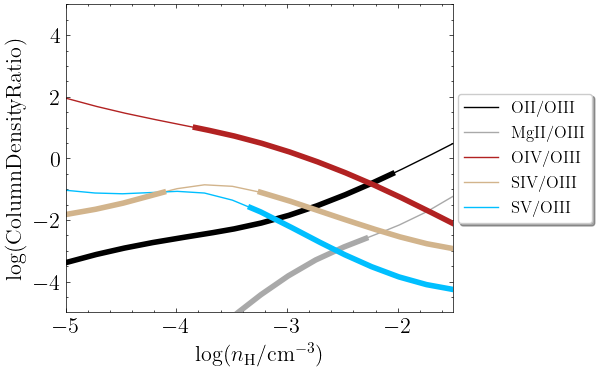

In [190]:
fig, ax = plt.subplots(1, figsize=(5,4))

plot_logN_ratio(ax, species_logN_interp, logN_ratio_dict)

ax.set_xlim(-5, -1.5)
ax.set_ylim(-5, 5)

In [191]:
pos = np.array(-2.8) + 1e-6 * np.random.randn(500, 1)
nwalkers, ndim = pos.shape

In [192]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_ratio_dict, species_logN_interp)
)

In [193]:
sampler.run_mcmc(pos, 500, progress=True);

100%|█████████████████████████████████████████| 500/500 [08:18<00:00,  1.00it/s]


In [194]:
flat_samples_hdens = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
                                columns=['log_hdens'])

flat_samples_hdens.to_csv(savedir+'hdens_hi.csv', index=False)

#flat_samples_hdens = pd.read_csv(savedir+'hdens_hi.csv')

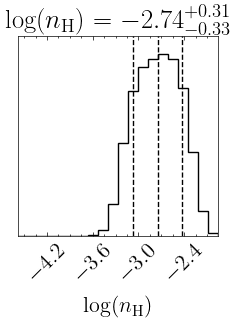

In [195]:
fig = corner.corner(
    flat_samples_hdens, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [196]:
grid_points_hdens = np.array([[12, log_hdens, -3] for log_hdens in flat_samples_hdens['log_hdens']])

In [197]:
logN_offset = 13.7-np.median(species_logN_interp['O+2'](grid_points_hdens))

In [198]:
logN_offset

5.116150161101334

Plot models

In [199]:
logN_dict = {
        #'HI':'14.3, -0.1, +0.1',
        #'HeI':'<12.8',
        #'CII':'<13.2',
        #'CIII':'>13.6',
        #'CIV':'13.96, -0.01, +0.01',
        #'NII':'<13.2',
        #'NIV':'13.0, -0.1, +0.1',
        #'NV':'<13.2',
        'OII':'<13.2',
        'OIII':'13.7, -0.2, +0.1',
        'OIV':'<14.67',
        #'OV':'14.19, -0.03, +0.03',
        #'OVI':'13.8, -0.2, +0.2',
        #'NeVI':'<13.5',
        #'NeVIII':'<13.5',
        'MgII':'<11.1',
        #'MgX':'<13.6',
        #'AlII':'<11.0',
        #'AlIII':'<11.3',
        #'SiII':'<12.1',
        #'SiIII':'<11.9',
        'SIV':'<12.6',
        'SV':'<12.1',}
        #'SVI':'<13.4',}
        #'FeII':'<11.5'}

In [200]:
sample_indices_hdens = np.random.randint(low=0, high=len(flat_samples_hdens), size=200)

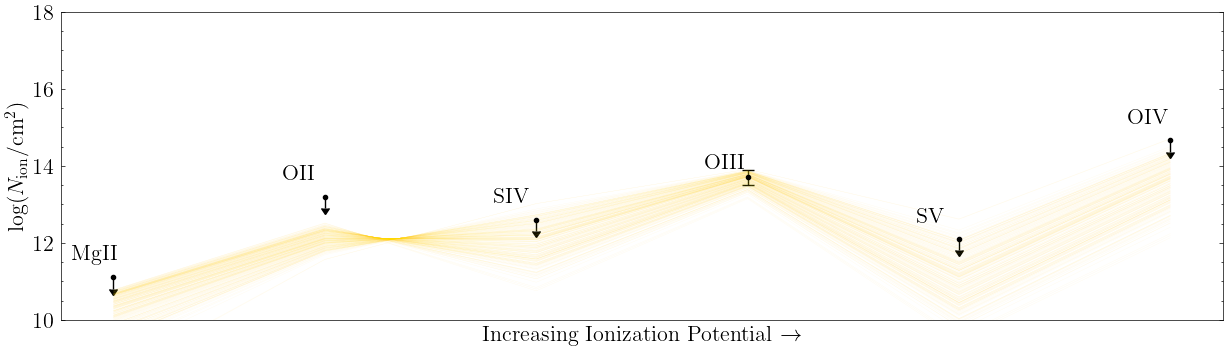

In [201]:
fig, ax = plot_column_densities_obs(logN_dict)

for i in range(len(sample_indices_hdens)):
    
    idx = sample_indices_hdens[i]
    flat_samples_row = flat_samples_hdens.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    
    logN_species_test = predict_col_dens(logN_dict, 12, log_hdens, 
                                         -3, species_logN_interp)

    # Plot
    ax.plot(np.arange(len(logN_species_test)), 
            np.array(logN_species_test)+logN_offset,
            color='gold', lw=.2, alpha=.1)

In [202]:
get_cloud_size(14.3, -2.7, species_logN_interp)

0.04333001535226151

Try out a solution

In [177]:
logN_HI_test = 14.34 #14.34
log_hdens_test = -1.5 #-3.5
log_metals_test = -2 #0.3

In [178]:
logN_species_test = predict_col_dens(logN_dict, logN_HI_test, log_hdens_test, 
                                     log_metals_test, species_logN_interp)

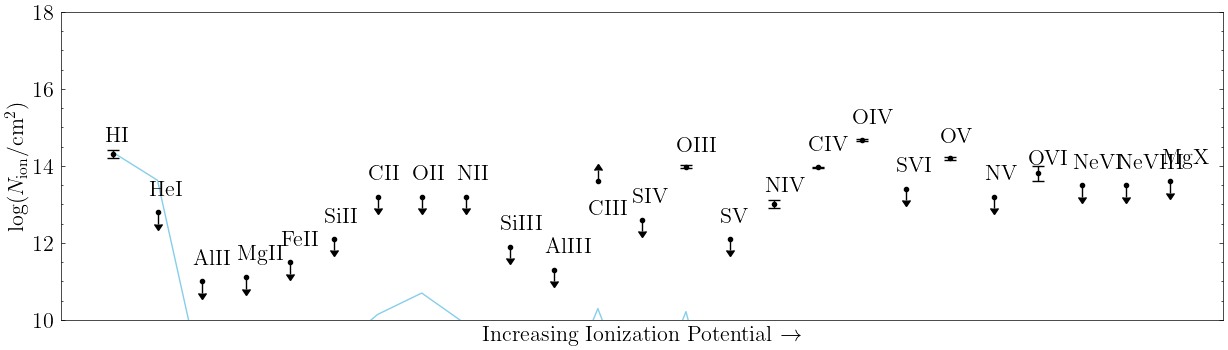

In [179]:
fig, ax = plot_column_densities_obs(logN_dict)
ax.plot(np.arange(len(logN_species_test)), np.array(logN_species_test),#+13.2-logN_species_test[7], 
        color='skyblue')

Get column density ratios

In [180]:
gen_logN_ratio_str(logN_dict['CIII'], logN_dict['OIII'])

'>-0.37, 0.33'

In [181]:
logN_ratio_dict = {'OII/OIII': '<-0.8, 0.2',
                   'SiII/OIII': '<-1.9, 0.2',
                   'MgII/OIII': '<-2.9, 0.2',
                   #'CIII/OIII': '>-0.4, 0.4'
                   }

Generate predicted column density ratios

(-4.0, 1.0)

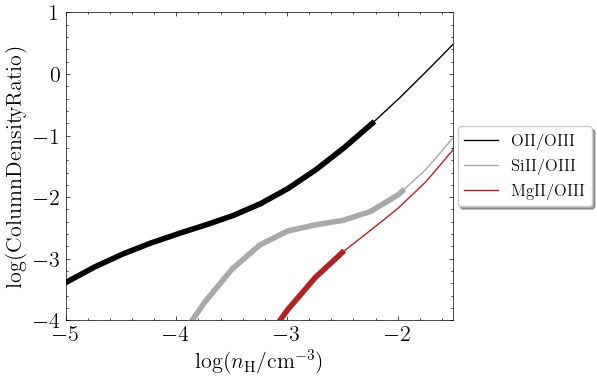

In [182]:
fig, ax = plt.subplots(1, figsize=(5,4))

plot_logN_ratio(ax, species_logN_interp, logN_ratio_dict)

ax.set_xlim(-5, -1.5)
ax.set_ylim(-4, 1)

In [132]:
pos = np.array(-2.7) + 1e-4 * np.random.randn(500, 1)
nwalkers, ndim = pos.shape

In [133]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_ratio_dict, species_logN_interp)
)

In [134]:
sampler.run_mcmc(pos, 500, progress=True);

100%|█████████████████████████████████████████| 500/500 [05:22<00:00,  1.55it/s]


In [135]:
flat_samples_hdens = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
                                columns=['log_hdens'])
#flat_samples_oxy_sul.to_csv(savedir+'oxy_sul_solar_flat.csv', index=False)

#flat_samples_oxy_sul = pd.read_csv(savedir+'oxy_sul_solar_flat.csv')

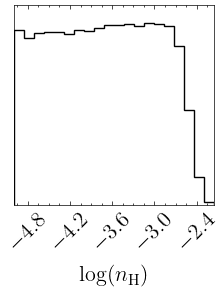

In [183]:
fig = corner.corner(
    flat_samples_hdens, #quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$', r'$[\mathrm{O/H}]$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

In [137]:
grid_points_hdens = np.array([[12, log_hdens, -3] for log_hdens in flat_samples_hdens['log_hdens']])

(array([ 1575.,  1728.,  1625.,  1800.,  1676.,  1551.,  1616.,  1581.,
         1503.,  1663.,  1570.,  1631.,  2040.,  2267.,  2107.,  2172.,
         2132.,  2196.,  2197.,  2274.,  2477.,  4054.,  4847.,  5789.,
         8747., 10340., 14718., 19491., 25868., 66765.]),
 array([6.96319017, 7.02448767, 7.08578517, 7.14708266, 7.20838016,
        7.26967766, 7.33097515, 7.39227265, 7.45357015, 7.51486764,
        7.57616514, 7.63746264, 7.69876013, 7.76005763, 7.82135513,
        7.88265263, 7.94395012, 8.00524762, 8.06654512, 8.12784261,
        8.18914011, 8.25043761, 8.3117351 , 8.3730326 , 8.4343301 ,
        8.49562759, 8.55692509, 8.61822259, 8.67952008, 8.74081758,
        8.80211508]),
 <BarContainer object of 30 artists>)

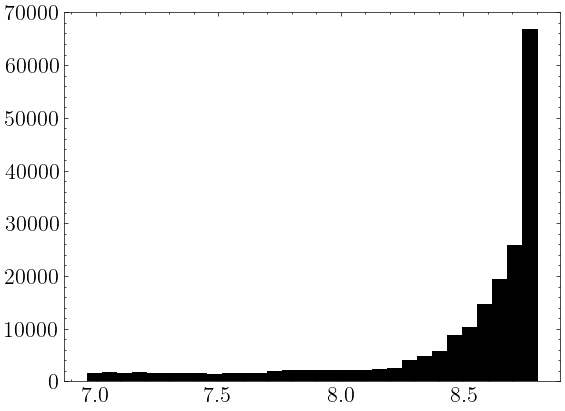

In [143]:
plt.hist(species_logN_interp['O+2'](grid_points_hdens), bins=30)

In [144]:
logN_offset = 13.97-np.median(species_logN_interp['O+2'](grid_points_hdens))

In [145]:
#log_metals_samples = -3+((14.40-logN_OIV_samples)-(16.4-12))

In [146]:
#plt.hist(log_metals_samples, bins=50)
#plt.xlabel(r'[O/H]')

In [147]:
#(np.round(np.percentile(log_metals_samples, 50), 2), 
#np.round(np.percentile(log_metals_samples, 50)-np.percentile(log_metals_samples, 100*(1-cdf_1sig)), 2),
#np.round(np.percentile(log_metals_samples, 50)-np.percentile(log_metals_samples, 100*cdf_1sig), 2))

In [148]:
logN_dict = {
        #'HI':'14.3, -0.1, +0.1',
        #'HeI':'<12.8',
        'CII':'<13.2',
        'CIII':'>13.6',
        'CIV':'13.96, -0.01, +0.01',
        'NII':'<13.2',
        'NIV':'13.0, -0.1, +0.1',
        'NV':'<13.2',
        'OII':'<13.2',
        'OIII':'13.97, -0.04, +0.04',
        'OIV':'14.67, -0.02, +0.02',
        'OV':'14.19, -0.03, +0.03',
        'OVI':'13.8, -0.2, +0.2',
        'NeVI':'<13.5',
        'NeVIII':'<13.5',
        'MgII':'<11.1',
        'MgX':'<13.6',
        'AlII':'<11.0',
        'AlIII':'<11.3',
        'SiII':'<12.1',
        'SiIII':'<11.9',
        'SIV':'<12.6',
        'SV':'<12.1',
        'SVI':'<13.4',
        'FeII':'<11.5'}

In [149]:
sample_indices_hdens = np.random.randint(low=0, high=len(flat_samples_hdens), size=200)

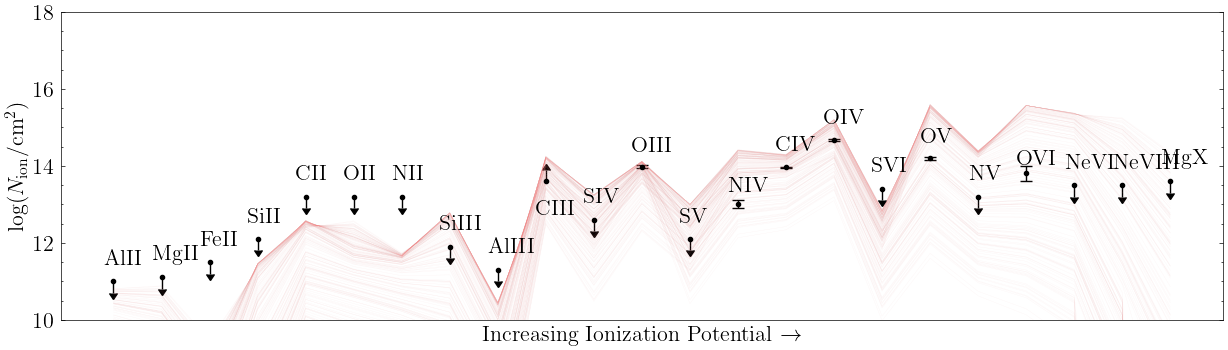

In [150]:
fig, ax = plot_column_densities_obs(logN_dict)

for i in range(len(sample_indices_hdens)):
    
    idx = sample_indices_hdens[i]
    flat_samples_row = flat_samples_hdens.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    
    logN_species_test = predict_col_dens(logN_dict, 12, log_hdens, 
                                         -3, species_logN_interp)

    # Plot
    ax.plot(np.arange(len(logN_species_test)), 
            np.array(logN_species_test)+logN_offset,
            color='lightcoral', lw=.2, alpha=.1)

# Oxygen fit

In [128]:
# Assume solar abundance patterns throughout

def lambda_log_prior(params):
    
    # Only parameters being varied
    log_hdens, log_metals = params
    
    # If the sampled density is within the CLOUDY limits
    # Avoid edges?
    if log_hdens_min<log_hdens<log_hdens_max and log_metals_min<log_metals<log_metals_max:
        return 0.0
    return -np.inf

In [129]:
def lambda_log_likelihood(params, logN_dict, species_logN_interp):

    # Only parameters being varied
    log_hdens, log_metals = params
    
    # Construct the full range of parameters
    # Empty dictionary means solar abundance patterns
    params_full = np.array([logN_HI_test, log_hdens, log_metals, {}])
    
    # Call the original likelihood function on the full set of parameters
    return log_likelihood(params_full, logN_dict, species_logN_interp)    

In [130]:
def log_probability(params, logN_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    # Params here will only contain n_H and [O/H]
    
    lp = lambda_log_prior(params)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + lambda_log_likelihood(params, logN_dict, species_logN_interp)

Isolate the ions

In [131]:
ions_oxy = ['OII', 'SiII', 'SiIII', 'MgII'] #['HeI', 'OII', 'OIII', 'OIV', 'CII', 'CIII', 'CIV']

In [132]:
logN_dict_oxy = {ion: logN_dict[ion] for ion in ions_oxy}

In [133]:
logN_dict_oxy

{'OII': '<13.2', 'SiII': '<12.1', 'SiIII': '<11.9', 'MgII': '<11.1'}

In [134]:
pos = np.array([log_hdens_test, log_metals_test]) + 1e-4 * np.random.randn(500, 2)
nwalkers, ndim = pos.shape

In [135]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_dict_oxy, species_logN_interp)
)

In [136]:
sampler.run_mcmc(pos, 500, progress=True)

100%|█████████████████████████████████████████| 500/500 [03:21<00:00,  2.48it/s]


State([[-1.28119819e+00 -1.98910533e+00]
 [-4.40107415e+00 -8.17789912e-01]
 [-2.24011780e+00 -1.90356305e+00]
 [-2.41266533e+00 -2.69274563e+00]
 [-9.77219985e-01 -1.91978655e+00]
 [-4.32943963e+00 -3.52163357e-01]
 [ 8.95804224e-01 -2.58632129e+00]
 [-9.32186205e-01 -2.01046275e+00]
 [-5.63662618e-01 -4.30155530e-01]
 [-4.32157174e+00  6.36806590e-01]
 [-1.01180348e+00 -1.60171435e-01]
 [-4.93721638e+00 -2.49721912e+00]
 [-4.33495923e+00  5.56986581e-01]
 [-3.85522160e+00 -1.31046943e+00]
 [-1.92407968e+00 -2.13399682e-01]
 [-3.82792592e+00 -1.07589231e+00]
 [-7.55093990e-01 -1.30361714e+00]
 [-4.60957981e+00 -1.95394528e+00]
 [-4.46628194e+00 -1.22558242e-01]
 [-4.63391654e+00 -6.82352949e-01]
 [-3.27115644e+00 -9.35720856e-01]
 [-4.11679000e+00 -1.38958105e+00]
 [-3.84530760e+00 -6.53252431e-01]
 [-3.95763665e-01 -2.81537689e+00]
 [ 9.41804717e-01  4.05246105e-01]
 [-1.71254585e+00 -8.09557551e-01]
 [ 1.42299414e-01 -2.59658556e-01]
 [-3.21799492e+00 -8.38197659e-01]
 [-3.49247870e

In [137]:
flat_samples_oxy = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
                                columns=['log_hdens', 'log_metals'])
flat_samples_oxy.to_csv(savedir+'oxy_solar_flat_c1.csv', index=False)

#flat_samples_oxy = pd.read_csv(savedir+'oxy_solar_flat_c1.csv')

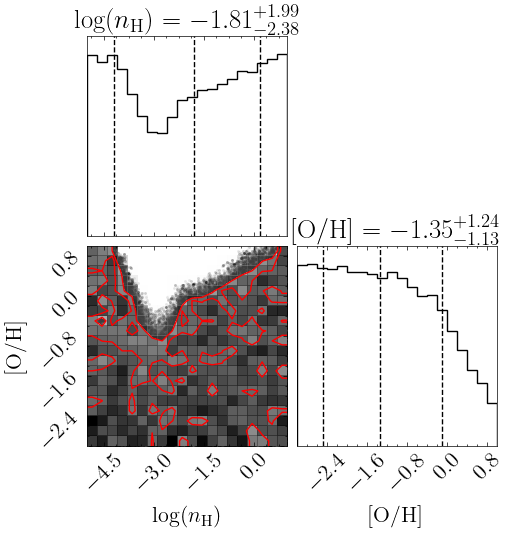

In [138]:
fig = corner.corner(
    flat_samples_oxy.loc[:, ['log_hdens', 'log_metals']], quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(n_\mathrm{H})$', r'$[\mathrm{O/H}]$'], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

Now plot the best models

In [139]:
logN_dict = {
        'HI':'14.34, -0.11, +0.13',
        'HeI':'<12.8',
        'CII':'<13.2',
        'CIII':'>13.6',
        'CIV':'13.96, -0.01, +0.01',
        'NII':'<13.2',
        'NIV':'13.02, -0.12, +0.12',
        'NV':'<13.2',
        'OII':'<13.2',
        'OIII':'14.28, -0.02, +0.02',
        'OIV':'14.67, -0.02, +0.02',
        'OV':'14.19, -0.03, +0.03',
        'OVI':'13.75, -0.15, +0.15',
        'NeVI':'<13.5',
        'NeVIII':'<13.5',
        'MgII':'<11.1',
        'MgX':'<13.6',
        'AlII':'<11.0',
        'AlIII':'<11.3',
        'SiII':'<12.1',
        'SiIII':'<11.9',
        'SIV':'<12.6',
        'SV':'<12.1',
        'SVI':'<13.4',
        'FeII':'<11.5'}

In [140]:
sample_indices_oxy = np.random.randint(low=0, high=len(flat_samples_oxy), size=200)

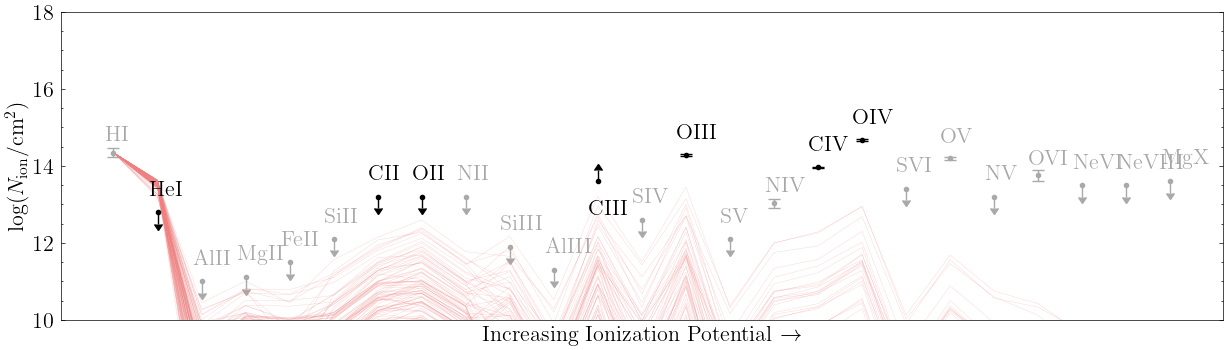

In [145]:
fig, ax = plot_column_densities_obs(logN_dict, gray_out=['HI', 
                                                         'NII', 'NIV', 'NV', 'OV', 'OVI',
                                                         'NeVI', 'NeVIII', 'MgII', 'MgX', 'AlII', 'AlIII',
                                                         'SiII', 'SiIII', 'SIV', 'SV', 'SVI', 'FeII'])

for i in range(len(sample_indices_oxy)):
    
    idx = sample_indices_oxy[i]
    flat_samples_row = flat_samples_oxy.iloc[i]
    log_hdens = flat_samples_row['log_hdens']
    log_metals = flat_samples_row['log_metals']
    
    if log_hdens > -3 and log_metals < 0:
        logN_species_test = predict_col_dens(logN_dict, logN_HI_test, log_hdens, 
                                             log_metals, species_logN_interp)

        # Plot
        ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='lightcoral', lw=.2, alpha=.5)

#ax.text(x=-0.5, y=17.3, s=r'$\log(n_\mathrm{H}) = -3.44 \pm 0.11$')
#ax.text(x=-0.5, y=16.5, s=r'$[\mathrm{O}/\mathrm{H}] = 0.06_{-0.06}^{+0.07}$')

#plt.savefig(savedir+'z=0_72882224_cloudy_oxy.pdf', dpi=300)

Plot the posterior for cloud size

In [94]:
flat_samples_oxy['logN_HII'] = [species_logN_interp['H+']([logN_HI_test,
                                                            flat_samples_oxy.iloc[i]['log_hdens'],
                                                            flat_samples_oxy.iloc[i]['log_metals']])[0]
                                               for i in range(len(flat_samples_oxy))]

In [95]:
flat_samples_oxy['cloud_size_kpc'] = ((10**logN_HI_test+10**flat_samples_oxy['logN_HII'])/10**flat_samples_oxy['log_hdens'])*3.24078e-19*1e-3

In [96]:
l_med = np.median(flat_samples_oxy['cloud_size_kpc'])
l_perc_16 = np.percentile(flat_samples_oxy['cloud_size_kpc'],16)
l_perc_84 = np.percentile(flat_samples_oxy['cloud_size_kpc'],84)

In [97]:
l_med, l_med-l_perc_16, l_perc_84-l_med

(0.8881469603739474, 0.0665502161898146, 0.07133055294415291)

In [98]:
#np.percentile(flat_samples_oxy['cloud_size_kpc'],100*cdf_3sig)

Text(0, 0.5, 'Probability Density')

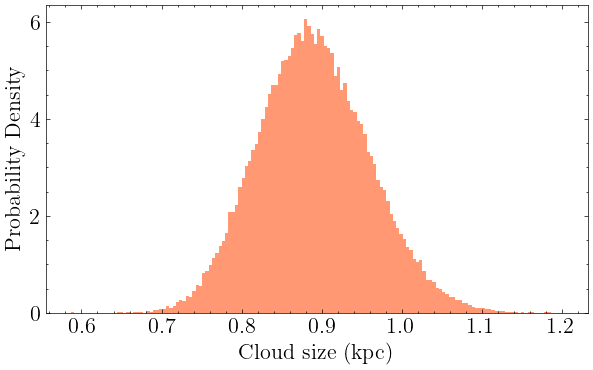

In [99]:
fig, ax = plt.subplots(1, figsize=(7,4))

ax.hist(flat_samples_oxy['cloud_size_kpc'], bins=150, density=True, color='coral', alpha=.8)
#ax.axvline(l_med, linestyle=':', lw=2)
#ax.axvline(l_perc_16, linestyle=':', lw=2)
#ax.axvline(l_perc_84, linestyle=':', lw=2)

#ax.text(140, 0.03, s=r'$\log N_{\mathrm{HI}} = 16.64 \pm 0.01$')
#ax.text(140, 0.022, s=r'$l < 200 \ \mathrm{kpc}$')

ax.set_xlabel('Cloud size (kpc)')
ax.set_ylabel('Probability Density')

# Hydrogen + Oxygen + Sulphur fit

# Two phase solution

If a gas cloud is composed of two phases ($n_{\mathrm{H,1}}$ and $n_{\mathrm{H,2}}$) of corresponding elemental abundances ($\mathrm{[X/H]}_{1}$ and $\mathrm{[X/H]}_{2}$) and HI column densities ($N_{\mathrm{HI, 1}}$ and $N_{\mathrm{HI, 2}}$), then the total ionic column density of $X_i$ can be written as -

$$N_{\mathrm{X_i}} = N_{\mathrm{HI,1}} \times \frac{f_{X_i,1}}{f_{\mathrm{HI,1}}} (n_{\mathrm{H,1}}) \times 10^{[\mathrm{X/H}]_1} + N_{\mathrm{HI, 2}} \times \frac{f_{X_i, 2}}{f_{\mathrm{HI, 2}}} (n_{\mathrm{H,2}}) \times 10^{[\mathrm{X/H}]_2}$$

The other constraining condition is -

$$N_{\mathrm{HI}} = N_{\mathrm{HI, 1}} + N_{\mathrm{HI, 2}}$$

We expect several degeneracies and consequently weaker constraints on each of these parameters.

In [107]:
logN_HI_p1_test = 14.0
log_hdens_p1_test = -3.27
log_metals_p1_test = 0.5

logN_HI_p2_test = 13.7
log_hdens_p2_test = -3.7
log_metals_p2_test = 0.5

In [108]:
logN_species_test_p1 = np.array(predict_col_dens(logN_dict, logN_HI_p1_test, log_hdens_p1_test, 
                                     log_metals_p1_test, species_logN_interp))

logN_species_test_p2 = np.array(predict_col_dens(logN_dict, logN_HI_p2_test, log_hdens_p2_test, 
                                     log_metals_p2_test, species_logN_interp))

logN_species_test = np.log10(10**logN_species_test_p1 + 10**logN_species_test_p2)

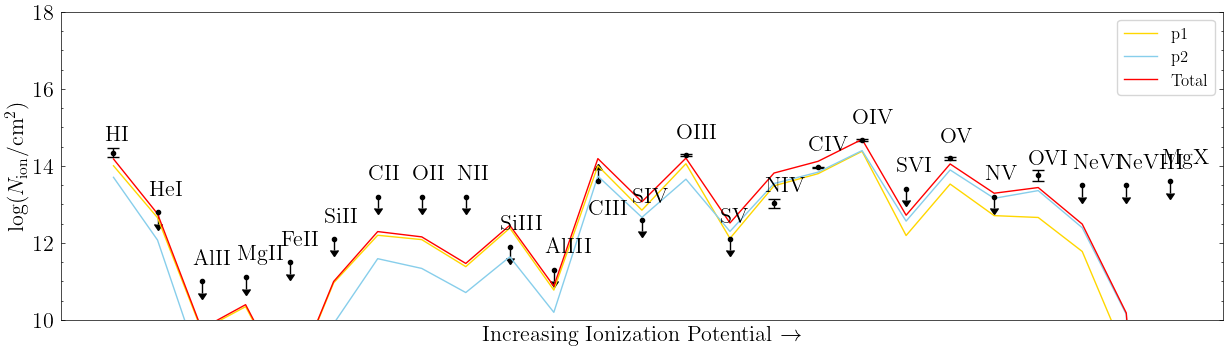

In [109]:
fig, ax = plot_column_densities_obs(logN_dict)

ax.plot(np.arange(len(logN_species_test)), logN_species_test_p1, color='gold', label='p1')
ax.plot(np.arange(len(logN_species_test)), logN_species_test_p2, color='skyblue', label='p2')
ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='red', label='Total')

ax.legend()

In [110]:
def log_probability(params, logN_dict, species_logN_interp):
    
    # Create the probability function using overridden prior and likelihood functions
    # Params here will only contain n_H and [O/H]
    
    lp = log_prior_tp(params)
    
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_tp(params, logN_dict, species_logN_interp)

In [111]:
ions_hyd_oxy_sul = ['HeI', 'OII', 'OIII', 'OIV', 'OV', 'OVI', 'CII', 'CIII', 'CIV']

In [112]:
logN_dict_hyd_oxy_sul = {ion: logN_dict[ion] for ion in ions_hyd_oxy_sul}

In [114]:
pos = np.array([logN_HI_p1_test, log_hdens_p1_test, log_metals_p1_test,
                logN_HI_p2_test, log_hdens_p2_test, log_metals_p2_test]) + 1e-4 * np.random.randn(500, 6)
nwalkers, ndim = pos.shape

In [115]:
sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(logN_dict_hyd_oxy_sul, species_logN_interp)
)

In [116]:
sampler.run_mcmc(pos, 500, progress=True);

100%|█████████████████████████████████████████████████████████████| 500/500 [11:58<00:00,  1.44s/it]


In [121]:
flat_samples_hyd_oxy_sul = pd.DataFrame(sampler.get_chain(discard=100, flat=True), 
                                columns=['logN_HI_p1', 'log_hdens_p1', 'log_metals_p1',
                                         'logN_HI_p2', 'log_hdens_p2', 'log_metals_p2'])
flat_samples_hyd_oxy_sul.to_csv(savedir+'hyd_oxy_sul_solar_flat_c1.csv', index=False)

#flat_samples_hyd_oxy_sul = pd.read_csv(savedir+'hyd_oxy_sul_solar_flat_c1.csv')

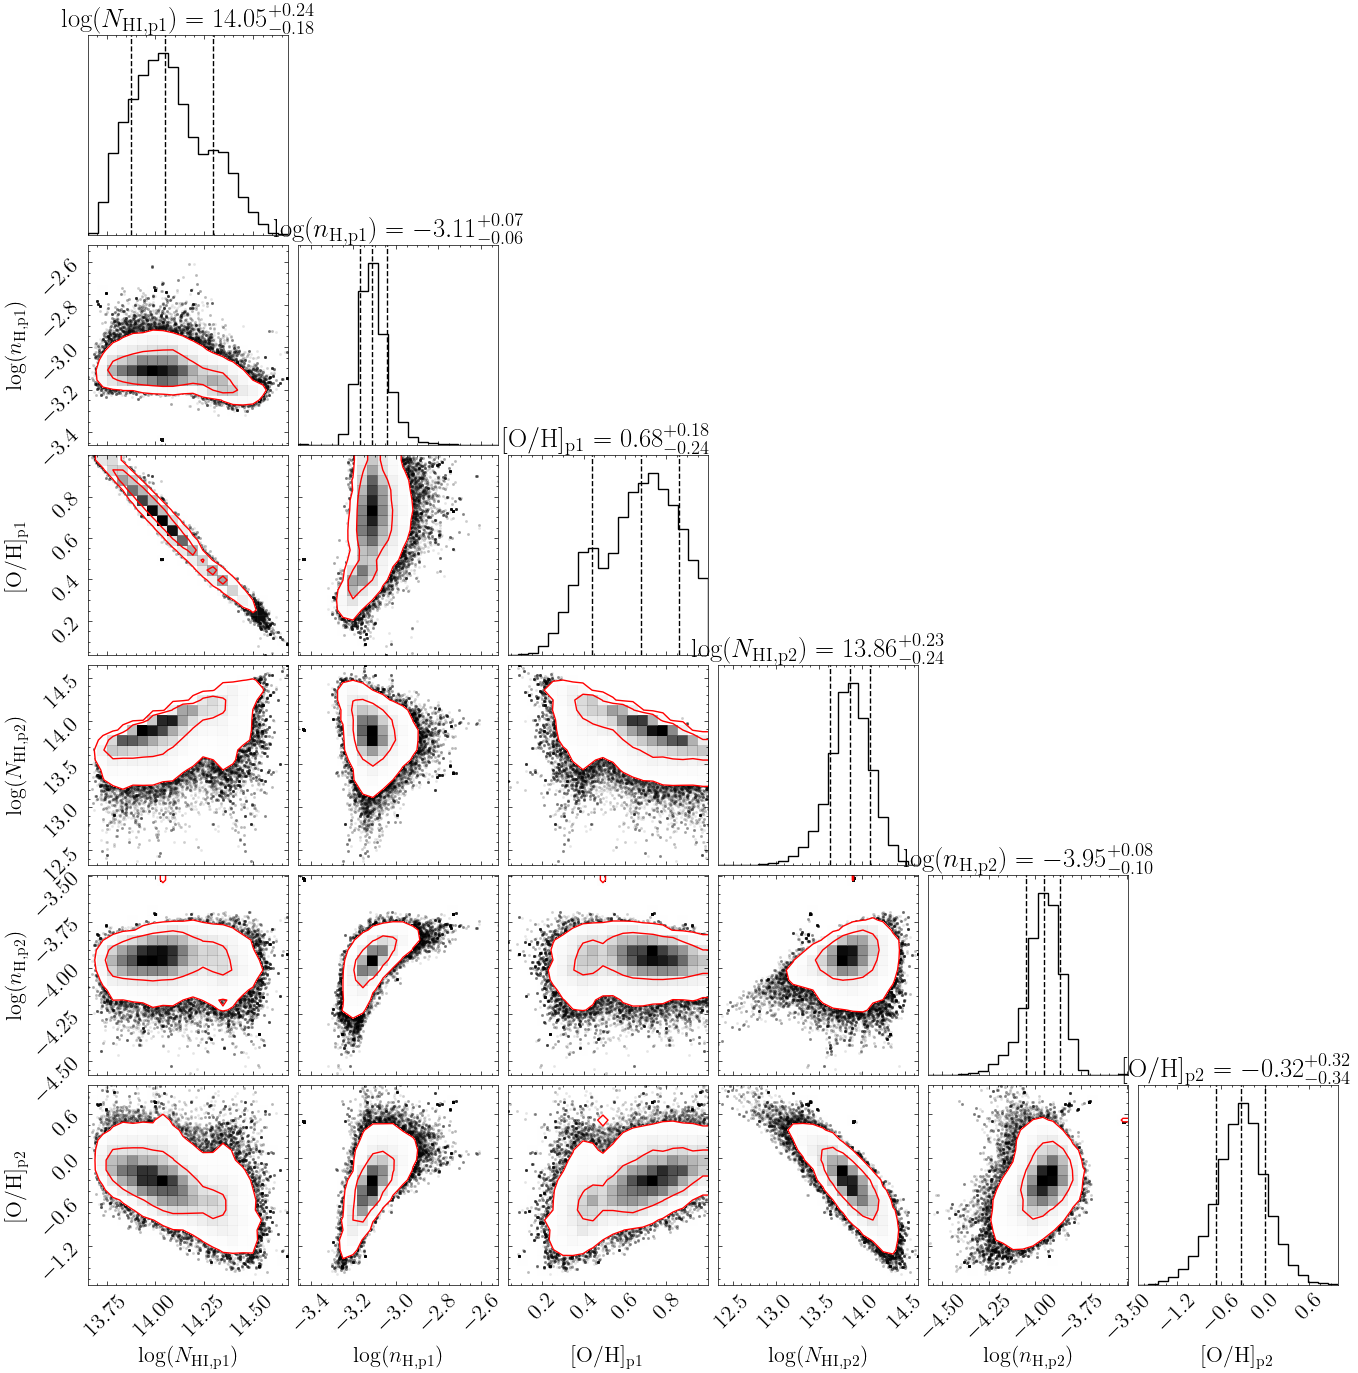

In [122]:
fig = corner.corner(
    flat_samples_hyd_oxy_sul, quantiles = [0.16, 0.5, 0.84], show_titles=True, 
    labels=[r'$\log(N_\mathrm{HI, p1})$', r'$\log(n_\mathrm{H, p1})$', r'$[\mathrm{O/H}]_{\mathrm{p1}}$',
            r'$\log(N_\mathrm{HI, p2})$', r'$\log(n_\mathrm{H, p2})$', r'$[\mathrm{O/H}]_{\mathrm{p2}}$',], 
    plot_density=True, levels=[0.68, 0.95], contour_kwargs={'colors':'red'}
);

Now plot the best models

In [123]:
logN_dict = {
        'HI':'14.34, -0.11, +0.13',
        'HeI':'<12.8',
        'CII':'<13.2',
        'CIII':'>13.6',
        'CIV':'13.96, -0.01, +0.01',
        'NII':'<13.2',
        'NIV':'13.02, -0.12, +0.12',
        'NV':'<13.2',
        'OII':'<13.2',
        'OIII':'14.28, -0.02, +0.02',
        'OIV':'14.67, -0.02, +0.02',
        'OV':'14.19, -0.03, +0.03',
        'OVI':'13.75, -0.15, +0.15',
        'NeVI':'<13.5',
        'NeVIII':'<13.5',
        'MgII':'<11.1',
        'MgX':'<13.6',
        'AlII':'<11.0',
        'AlIII':'<11.3',
        'SiII':'<12.1',
        'SiIII':'<11.9',
        'SIV':'<12.6',
        'SV':'<12.1',
        'SVI':'<13.4',
        'FeII':'<11.5'}

In [124]:
sample_indices_hyd_oxy_sul = np.random.randint(low=0, high=len(flat_samples_hyd_oxy_sul), size=200)

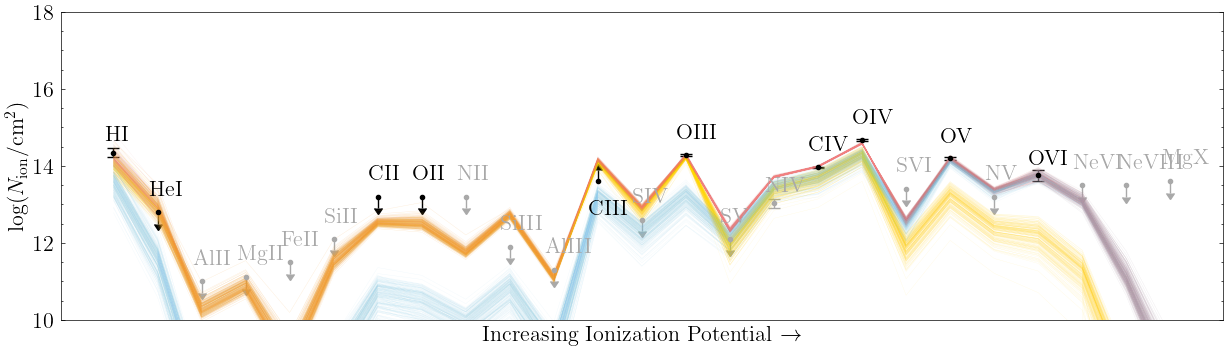

In [126]:
fig, ax = plot_column_densities_obs(logN_dict, gray_out=['NII', 'NIV', 'NV', 
                                                         'NeVI', 'NeVIII', 'MgII', 'MgX', 'AlII', 'AlIII',
                                                         'SiII', 'SiIII', 'SIV', 'SV', 'SVI', 'FeII'])

for i in range(len(sample_indices_hyd_oxy_sul)):
    
    idx = sample_indices_hyd_oxy_sul[i]
    flat_samples_row = flat_samples_hyd_oxy_sul.iloc[i]
    
    logN_HI_p1 = flat_samples_row['logN_HI_p1']
    log_hdens_p1 = flat_samples_row['log_hdens_p1']
    log_metals_p1 = flat_samples_row['log_metals_p1']

    logN_species_test_p1 = np.array(predict_col_dens(logN_dict, logN_HI_p1, log_hdens_p1, 
                                         log_metals_p1, species_logN_interp))
    
    logN_HI_p2 = flat_samples_row['logN_HI_p2']
    log_hdens_p2 = flat_samples_row['log_hdens_p2']
    log_metals_p2 = flat_samples_row['log_metals_p2']
    
    logN_species_test_p2 = np.array(predict_col_dens(logN_dict, logN_HI_p2, log_hdens_p2, 
                                         log_metals_p2, species_logN_interp))
    
    logN_species_test = np.log10(10**logN_species_test_p1 + 10**logN_species_test_p2)
        
    # Plot
    ax.plot(np.arange(len(logN_species_test)), logN_species_test_p1, color='gold', lw=.2, alpha=.15)
    ax.plot(np.arange(len(logN_species_test)), logN_species_test_p2, color='skyblue', lw=.2, alpha=.15)

    ax.plot(np.arange(len(logN_species_test)), logN_species_test, color='lightcoral', lw=.2, alpha=.15)

#ax.text(x=-0.5, y=17.3, s=r'$\log(n_\mathrm{H}) = -3.34 \pm 0.03$')
#ax.text(x=-0.5, y=16.5, s=r'$[\mathrm{O}/\mathrm{H}] = -0.66 \pm 0.02$')

#plt.savefig(savedir+'z=1_1659134_cloudy_hyd_oxy_c1.pdf', dpi=300)